# **Applied Seismology II: Processing the 2025 Marmara Earthquake**

## **A data-processing workflow built around one real event**

This notebook follows one earthquake through a sequence of standard processing decisions that seismologists make all the time:

1. define the event and metadata,
2. download and inspect the waveform data,
3. compare stations and instrument types,
4. choose one station for a clear processing workflow,
5. study RMS, detrending, filtering, spectra, spectrograms, and response removal,
6. return to the multi-station view for arrivals and phase picking.

### **Learning goals**

By the end of the practical, you should be able to:

- retrieve `Catalog`, `Inventory`, and `Stream` objects for a real earthquake,
- explain why channel codes such as `HNZ` and `HHZ` already contain physically useful information,
- justify which sensor types are the safer choice for different mainshocks,
- use RMS to compare vertical and horizontal components,
- explain why detrending should precede filtering,
- compare high-pass, low-pass, and band-pass choices for the same record,
- interpret amplitude spectra and spectrograms,
- remove the instrument response with sensible `pre_filt` choices,
- compare `STA/LTA` detections and `PhaseNet` picks critically.




---

## **Setup**

We will use:

- `ObsPy` for catalog access, metadata, waveform handling, filtering, and triggering,
- `matplotlib` and `cartopy` for plotting,
- `ipywidgets` for interactive exploration,
- `SeisBench` for `PhaseNet`.

The figures are created with `matplotlib` and `cartopy`.


In [1]:
# If needed in a fresh environment, uncomment once:
%pip install -q obspy seisbench cartopy ipywidgets scipy pandas nbformat

from pathlib import Path
import warnings

import ipywidgets as widgets
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, clear_output, display
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec
from scipy.signal import spectrogram as scipy_spectrogram

from obspy import UTCDateTime, read, read_events, read_inventory
from obspy.clients.fdsn import Client
from obspy.geodetics import gps2dist_azimuth, locations2degrees
from obspy.signal.trigger import ar_pick, classic_sta_lta, trigger_onset
import seisbench.models as sbm ##Seis

try:
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature

    HAS_CARTOPY = True
except Exception as exc:
    HAS_CARTOPY = False
    print(f"Cartopy is not available: {exc}")

warnings.filterwarnings("ignore", message=".*is not a valid QuakeML URI.*")
warnings.filterwarnings("ignore", message=".*divide by zero encountered in matmul.*")
warnings.filterwarnings("ignore", message=".*overflow encountered in matmul.*")
warnings.filterwarnings("ignore", message=".*invalid value encountered in matmul.*")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.3/15.3 MB 42.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 254.6/254.6 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 35.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 34.5 MB/s eta 0:00:00


In [2]:
# Resolve the repository root robustly so that the notebook also works
# when launched from the notebook folder instead of the repo root.
candidate_roots = [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]
for candidate in candidate_roots:
    if (candidate / "data").exists() and (candidate / "output" / "jupyter-notebook").exists():
        REPO_ROOT = candidate.resolve()
        break
else:
    REPO_ROOT = Path.cwd().resolve()

CACHE_DIR = REPO_ROOT / "data" / "fdsn_cache_20250423_marmara_multistation"
CACHE_DIR.mkdir(parents=True, exist_ok=True)

EVENT_FILE = CACHE_DIR / "event.xml"
STATION_FILE = CACHE_DIR / "stations.xml"
WAVEFORM_FILE = CACHE_DIR / "waveforms.mseed"

EVENT_SEARCH_START = UTCDateTime("2025-04-23T09:48:00")
EVENT_SEARCH_END = UTCDateTime("2025-04-23T09:50:30")

PRE_EVENT_S = 20.0
POST_EVENT_S = 360.0

STATION_ORDER = ["OSMT", "BIGA", "BGKT", "ADVT", "BOTS"]
PREFERRED_PREFIX = {
    "OSMT": "HN",
    "BIGA": "HN",
    "BGKT": "HH",
    "ADVT": "HH",
    "BOTS": "HN",
}

REQUESTS = [
    ("KO", "OSMT", "*", "HN?"),
    ("KO", "BIGA", "*", "HN?"),
    ("KO", "BGKT", "*", "HH?"),
    ("KO", "ADVT", "*", "HH?"),
    ("KO", "BOTS", "*", "HN?"),
    ("KO", "BOTS", "*", "HH?"),
]

DESIRED_TRACE_IDS = {
    "KO.OSMT..HNZ", "KO.OSMT..HNN", "KO.OSMT..HNE",
    "KO.BIGA..HNZ", "KO.BIGA..HNN", "KO.BIGA..HNE",
    "KO.BGKT..HHZ", "KO.BGKT..HHN", "KO.BGKT..HHE",
    "KO.ADVT..HHZ", "KO.ADVT..HHN", "KO.ADVT..HHE",
    "KO.BOTS..HNZ", "KO.BOTS..HNN", "KO.BOTS..HNE",
    "KO.BOTS..HHZ", "KO.BOTS..HHN", "KO.BOTS..HHE",
}

FAMILY_ORDER = {"HN": 0, "HH": 1}
COMPONENT_ORDER = {"Z": 0, "N": 1, "E": 2, "1": 1, "2": 2}

print(f"Repository root : {REPO_ROOT}")
print(f"Cache directory : {CACHE_DIR}")

Repository root : /content
Cache directory : /content/data/fdsn_cache_20250423_marmara_multistation


---

## **Download the catalog entry**

We start with the event definition, because every later timing choice depends on:

- the **origin time**,
- the **epicenter**,
- the **depth**,
- the **magnitude**.

The event is fetched from the **USGS FDSN event service** and then cached locally.


In [3]:
if EVENT_FILE.exists():
    catalog = read_events(str(EVENT_FILE))
    print(f"Loaded cached event file: {EVENT_FILE}")
else:
    event_client = Client("USGS")
    catalog = event_client.get_events(
        starttime=EVENT_SEARCH_START,
        endtime=EVENT_SEARCH_END,
        minmagnitude=6.0,
    )
    catalog.write(str(EVENT_FILE), format="QUAKEML")
    print(f"Downloaded and cached event file: {EVENT_FILE}")

event = catalog[0]
preferred_origin = event.preferred_origin() or event.origins[0]
preferred_magnitude = event.preferred_magnitude() or event.magnitudes[0]

origin_time = preferred_origin.time
event_lat = preferred_origin.latitude
event_lon = preferred_origin.longitude
event_depth_km = preferred_origin.depth / 1000.0

starttime = origin_time - PRE_EVENT_S
endtime = origin_time + POST_EVENT_S

event_summary = pd.DataFrame(
    [
        {
            "origin_time_utc": str(origin_time),
            "requested_window_start_utc": str(starttime),
            "requested_window_end_utc": str(endtime),
            "window_length_s": POST_EVENT_S + PRE_EVENT_S,
            "latitude_deg": event_lat,
            "longitude_deg": event_lon,
            "depth_km": event_depth_km,
            "magnitude": preferred_magnitude.mag,
            "magnitude_type": preferred_magnitude.magnitude_type,
        }
    ]
)
display(event_summary)


Downloaded and cached event file: /content/data/fdsn_cache_20250423_marmara_multistation/event.xml


,origin_time_utc,requested_window_start_utc,requested_window_end_utc,window_length_s,latitude_deg,longitude_deg,depth_km,magnitude,magnitude_type
0,2025-04-23T09:49:11.631000Z,2025-04-23T09:48:51.631000Z,2025-04-23T09:55:11.631000Z,380.0,40.8342,28.1897,12.736,6.2,mww


---

## **Download the station metadata (`Inventory`)**

We request `level="response"`. That is important because later sections need:

- station coordinates for mapping and geometry,
- channel codes for interpreting instrument families,
- full instrument responses for `remove_response()`.


In [4]:
if STATION_FILE.exists():
    inventory = read_inventory(str(STATION_FILE))
    print(f"Loaded cached station file: {STATION_FILE}")
else:
    data_client = Client("KOERI")
    inventory = data_client.get_stations(
        network="KO",
        station="OSMT,BIGA,BGKT,ADVT,BOTS",
        channel="HN?,HH?",
        starttime=starttime,
        endtime=endtime,
        level="response",
    )
    inventory.write(str(STATION_FILE), format="STATIONXML")
    print(f"Downloaded and cached station file: {STATION_FILE}")

station_rows = []
for network in inventory:
    for station in network:
        channel_codes = sorted(channel.code for channel in station)
        station_rows.append(
            {
                "station": station.code,
                "latitude_deg": station.latitude,
                "longitude_deg": station.longitude,
                "elevation_m": station.elevation,
                "channel_families": ", ".join(
                    prefix
                    for prefix in ["HN", "HH"]
                    if prefix in {code[:2] for code in channel_codes}
                ),
                "channels": ", ".join(channel_codes),
            }
        )

station_table = pd.DataFrame(station_rows)
station_table["station"] = pd.Categorical(station_table["station"], STATION_ORDER, ordered=True)
station_table = station_table.sort_values("station").reset_index(drop=True)
display(station_table)


Downloaded and cached station file: /content/data/fdsn_cache_20250423_marmara_multistation/stations.xml


,station,latitude_deg,longitude_deg,elevation_m,channel_families,channels
0,OSMT,40.60090,29.70000,798.0,HN,"HNE, HNN, HNZ"
1,BIGA,40.28134,27.15048,60.0,HN,"HNE, HNN, HNZ"
2,BGKT,41.18100,28.77300,80.0,HH,"HHE, HHN, HHZ"
3,ADVT,40.43320,29.73830,193.0,HH,"HHE, HHN, HHZ"
4,BOTS,40.99020,27.98100,30.0,"HN, HH","HHE, HHN, HHZ, HNE, HNN, HNZ"


---

## **Download the waveform data (`Stream`)**

We download the exact waveform set requested for the practical:

- `KO.OSMT HN*`
- `KO.BIGA HN*`
- `KO.BGKT HH*`
- `KO.ADVT HH*`
- `KO.BOTS HN*`
- `KO.BOTS HH*`

The requested time window is the one you specified:

$$
t \in [t_0 - 20\ \mathrm{s},\ t_0 + 360\ \mathrm{s}]
$$

where $t_0$ is the event origin time.


In [5]:
def waveform_cache_matches_request(stream, desired_ids, starttime, endtime, tolerance_s=5.0):
    # Validate that the cached waveform file really matches the requested
    # requested window. This avoids silently reusing the older 0 to +360 s cache.
    try:
        test_stream = stream.copy()
        for trace in test_stream:
            trace.data = trace.data.astype(float)
        test_stream.merge(method=1, fill_value="interpolate")
    except Exception:
        return False

    available_ids = {trace.id for trace in test_stream}
    if not desired_ids.issubset(available_ids):
        return False

    for trace_id in sorted(desired_ids):
        trace = test_stream.select(id=trace_id)[0]
        if trace.stats.starttime > starttime + tolerance_s:
            return False
        if trace.stats.endtime < endtime - tolerance_s:
            return False

    return True


need_waveform_download = True
if WAVEFORM_FILE.exists():
    cached_stream = read(str(WAVEFORM_FILE))
    if waveform_cache_matches_request(cached_stream, DESIRED_TRACE_IDS, starttime, endtime):
        st_raw = cached_stream
        need_waveform_download = False
        print(f"Loaded cached waveform file: {WAVEFORM_FILE}")
    else:
        print("Cached waveform file does not match the requested [-20 s, +360 s] window. Re-downloading.")

if need_waveform_download:
    data_client = Client("KOERI")
    bulk_requests = [
        (network, station, location, channel, starttime, endtime)
        for network, station, location, channel in REQUESTS
    ]
    st_raw = data_client.get_waveforms_bulk(bulk_requests)
    st_raw.write(str(WAVEFORM_FILE), format="MSEED")
    print(f"Downloaded and cached waveform file: {WAVEFORM_FILE}")


Downloaded and cached waveform file: /content/data/fdsn_cache_20250423_marmara_multistation/waveforms.mseed


In [6]:
waveform_rows = []
for trace_id in sorted({trace.id for trace in st_raw}):
    pieces = sorted(st_raw.select(id=trace_id), key=lambda tr: tr.stats.starttime)
    waveform_rows.append(
        {
            "trace_id": trace_id,
            "segments": len(pieces),
            "start_utc": str(pieces[0].stats.starttime),
            "end_utc": str(pieces[-1].stats.endtime),
            "duration_s": round(sum(tr.stats.npts * tr.stats.delta for tr in pieces), 2),
            "sampling_rate_hz": pieces[0].stats.sampling_rate,
        }
    )

waveform_table = pd.DataFrame(waveform_rows)
display(waveform_table)

# Build two merged versions:
# - st_plot keeps NaNs for plotting-friendly padding.
# - st_proc keeps zeros for dense arrays needed by filters and pickers.
st_plot = st_raw.copy()
for trace in st_plot:
    trace.data = trace.data.astype(float)
st_plot.merge(method=1, fill_value="interpolate")
st_plot.trim(starttime, endtime, pad=True, fill_value=np.nan)

st_proc = st_raw.copy()
for trace in st_proc:
    trace.data = trace.data.astype(float)
st_proc.merge(method=1, fill_value="interpolate")
st_proc.trim(starttime, endtime, pad=True, fill_value=0.0)


,trace_id,segments,start_utc,end_utc,duration_s,sampling_rate_hz
0,KO.ADVT..HHE,30,2025-04-23T09:48:50.270000Z,2025-04-23T09:55:12.090000Z,381.83,100.0
1,KO.ADVT..HHN,21,2025-04-23T09:48:51.060000Z,2025-04-23T09:55:13.560000Z,382.51,100.0
2,KO.ADVT..HHZ,26,2025-04-23T09:48:47.870000Z,2025-04-23T09:55:13.520000Z,385.66,100.0
3,KO.BGKT..HHE,1,2025-04-23T09:48:51.470000Z,2025-04-23T09:55:13.290000Z,381.83,100.0
4,KO.BGKT..HHN,1,2025-04-23T09:48:51.380000Z,2025-04-23T09:55:13.300000Z,381.93,100.0
5,KO.BGKT..HHZ,1,2025-04-23T09:48:51.000000Z,2025-04-23T09:55:13.010000Z,382.02,100.0
6,KO.BIGA..HNE,1,2025-04-23T09:48:47.500000Z,2025-04-23T09:55:15.480000Z,387.99,100.0
7,KO.BIGA..HNN,1,2025-04-23T09:48:51.310000Z,2025-04-23T09:55:14.070000Z,382.77,100.0
8,KO.BIGA..HNZ,1,2025-04-23T09:48:45.980000Z,2025-04-23T09:55:15.370000Z,389.40,100.0
9,KO.BOTS..HHE,1,2025-04-23T09:48:49.500000Z,2025-04-23T09:55:12.220000Z,382.73,100.0


18 Trace(s) in Stream:
KO.ADVT..HHE | 2025-04-23T09:48:51.630000Z - 2025-04-23T09:55:11.630000Z | 100.0 Hz, 38001 samples
KO.ADVT..HHN | 2025-04-23T09:48:51.630000Z - 2025-04-23T09:55:11.630000Z | 100.0 Hz, 38001 samples
KO.ADVT..HHZ | 2025-04-23T09:48:51.630000Z - 2025-04-23T09:55:11.630000Z | 100.0 Hz, 38001 samples
KO.BGKT..HHE | 2025-04-23T09:48:51.630000Z - 2025-04-23T09:55:11.630000Z | 100.0 Hz, 38001 samples
KO.BGKT..HHN | 2025-04-23T09:48:51.630000Z - 2025-04-23T09:55:11.630000Z | 100.0 Hz, 38001 samples
KO.BGKT..HHZ | 2025-04-23T09:48:51.630000Z - 2025-04-23T09:55:11.630000Z | 100.0 Hz, 38001 samples
KO.BIGA..HNE | 2025-04-23T09:48:51.630000Z - 2025-04-23T09:55:11.630000Z | 100.0 Hz, 38001 samples
KO.BIGA..HNN | 2025-04-23T09:48:51.630000Z - 2025-04-23T09:55:11.630000Z | 100.0 Hz, 38001 samples
KO.BIGA..HNZ | 2025-04-23T09:48:51.630000Z - 2025-04-23T09:55:11.630000Z | 100.0 Hz, 38001 samples
KO.BOTS..HHE | 2025-04-23T09:48:51.630000Z - 2025-04-23T09:55:11.630000Z | 100.0 Hz, 3

---

## **Geometry: stations and epicenter**

Before interpreting any waveform, it is worth constructing the geometric picture:

- Where is the source?
- Which stations are close or far?
- Which stations combine path effects and instrument effects in the most useful way?

This section is also where the later arrival-time discussion begins, because travel-time predictions depend on distance and depth from the beginning.


In [7]:
geometry_rows = []
for network in inventory:
    for station in network:
        distance_m, azimuth_deg, backazimuth_deg = gps2dist_azimuth(
            event_lat,
            event_lon,
            station.latitude,
            station.longitude,
        )
        distance_deg = locations2degrees(
            event_lat,
            event_lon,
            station.latitude,
            station.longitude,
        )

        channel_codes = sorted(channel.code for channel in station)
        geometry_rows.append(
            {
                "station": station.code,
                "latitude_deg": station.latitude,
                "longitude_deg": station.longitude,
                "distance_km": distance_m / 1000.0,
                "distance_deg": distance_deg,
                "azimuth_deg": azimuth_deg,
                "backazimuth_deg": backazimuth_deg,
                "families": ", ".join(
                    prefix
                    for prefix in ["HN", "HH"]
                    if prefix in {code[:2] for code in channel_codes}
                ),
                "preferred_family": PREFERRED_PREFIX[station.code],
            }
        )

station_geometry = pd.DataFrame(geometry_rows)
station_geometry["station"] = pd.Categorical(station_geometry["station"], STATION_ORDER, ordered=True)
station_geometry = station_geometry.sort_values("station").reset_index(drop=True)
display(station_geometry)


,station,latitude_deg,longitude_deg,distance_km,distance_deg,azimuth_deg,backazimuth_deg,families,preferred_family
0,OSMT,40.60090,29.70000,130.211789,1.168224,100.983005,281.968255,HN,HN
1,BIGA,40.28134,27.15048,107.311274,0.963856,235.442555,54.766820,HN,HN
2,BGKT,41.18100,28.77300,62.379211,0.560373,51.681860,232.064601,HH,HH
3,ADVT,40.43320,29.73830,138.368912,1.241723,108.267281,289.275803,HH,HH
4,BOTS,40.99020,27.98100,24.683239,0.221835,314.644579,134.507901,"HN, HH",HN


/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_ocean.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_cultural/ne_10m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


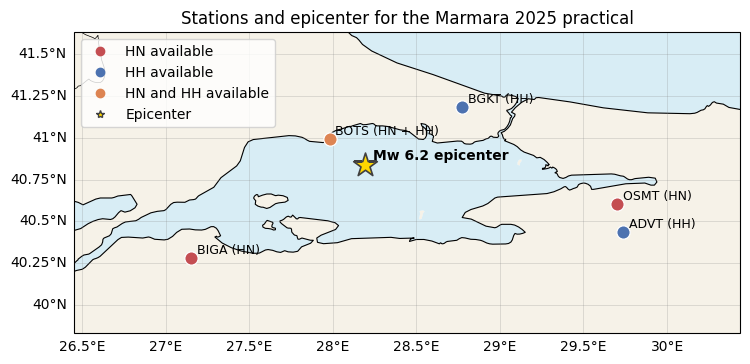

In [8]:
lon_margin = 0.7
lat_margin = 0.45

fig = plt.figure(figsize=(8.6, 7.2))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent(
      [
          station_geometry["longitude_deg"].min() - lon_margin,
          station_geometry["longitude_deg"].max() + lon_margin,
          min(station_geometry["latitude_deg"].min(), event_lat) - lat_margin,
          max(station_geometry["latitude_deg"].max(), event_lat) + lat_margin,
      ],
      crs=ccrs.PlateCarree(),
)

ax.add_feature(cfeature.LAND, facecolor="#f6f2e8")
ax.add_feature(cfeature.OCEAN, facecolor="#d8edf5")
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
gl = ax.gridlines(draw_labels=True, linewidth=0.4, color="0.5", alpha=0.4)
gl.top_labels = False
gl.right_labels = False

family_colors = {"HN": "#c44e52", "HH": "#4c72b0", "HN, HH": "#dd8452"}

ax.scatter(
    event_lon,
    event_lat,
    marker="*",
    s=320,
    color="gold",
    edgecolor="0.25",
    linewidth=1.2,
    transform=ccrs.PlateCarree() if HAS_CARTOPY else None,
    zorder=5,
)
ax.text(
    event_lon + 0.05,
    event_lat + 0.03,
    "Mw 6.2 epicenter",
    fontsize=10,
    weight="bold",
    transform=ccrs.PlateCarree() if HAS_CARTOPY else None,
)

for row in station_geometry.itertuples():
    color = family_colors.get(row.families, "0.2")
    ax.scatter(
        row.longitude_deg,
        row.latitude_deg,
        s=92,
        color=color,
        edgecolor="white",
        linewidth=0.9,
        transform=ccrs.PlateCarree() if HAS_CARTOPY else None,
        zorder=4,
    )
    family_label = row.families.replace(", ", " + ")
    ax.text(
        row.longitude_deg + 0.035,
        row.latitude_deg + 0.025,
        f"{row.station} ({family_label})",
        fontsize=9,
        transform=ccrs.PlateCarree() if HAS_CARTOPY else None,
    )

legend_handles = [
    plt.Line2D([], [], marker="o", linestyle="", color=family_colors["HN"], label="HN available"),
    plt.Line2D([], [], marker="o", linestyle="", color=family_colors["HH"], label="HH available"),
    plt.Line2D([], [], marker="o", linestyle="", color=family_colors["HN, HH"], label="HN and HH available"),
    plt.Line2D([], [], marker="*", linestyle="", color="gold", markeredgecolor="0.25", label="Epicenter"),
]
ax.legend(handles=legend_handles, loc="upper left")
ax.set_title("Stations and epicenter for the Marmara 2025 practical")
plt.show()


---

## **Raw trace overview by station**

We now inspect the raw records as they come from the service.

Important: this figure is still in **counts**. That means it is good for:

- onset timing,
- waveform-shape comparison,
- sensor-behavior diagnostics,
- qualitative station comparison.

But it is **not yet** appropriate for physical amplitude comparison between different instrument types.


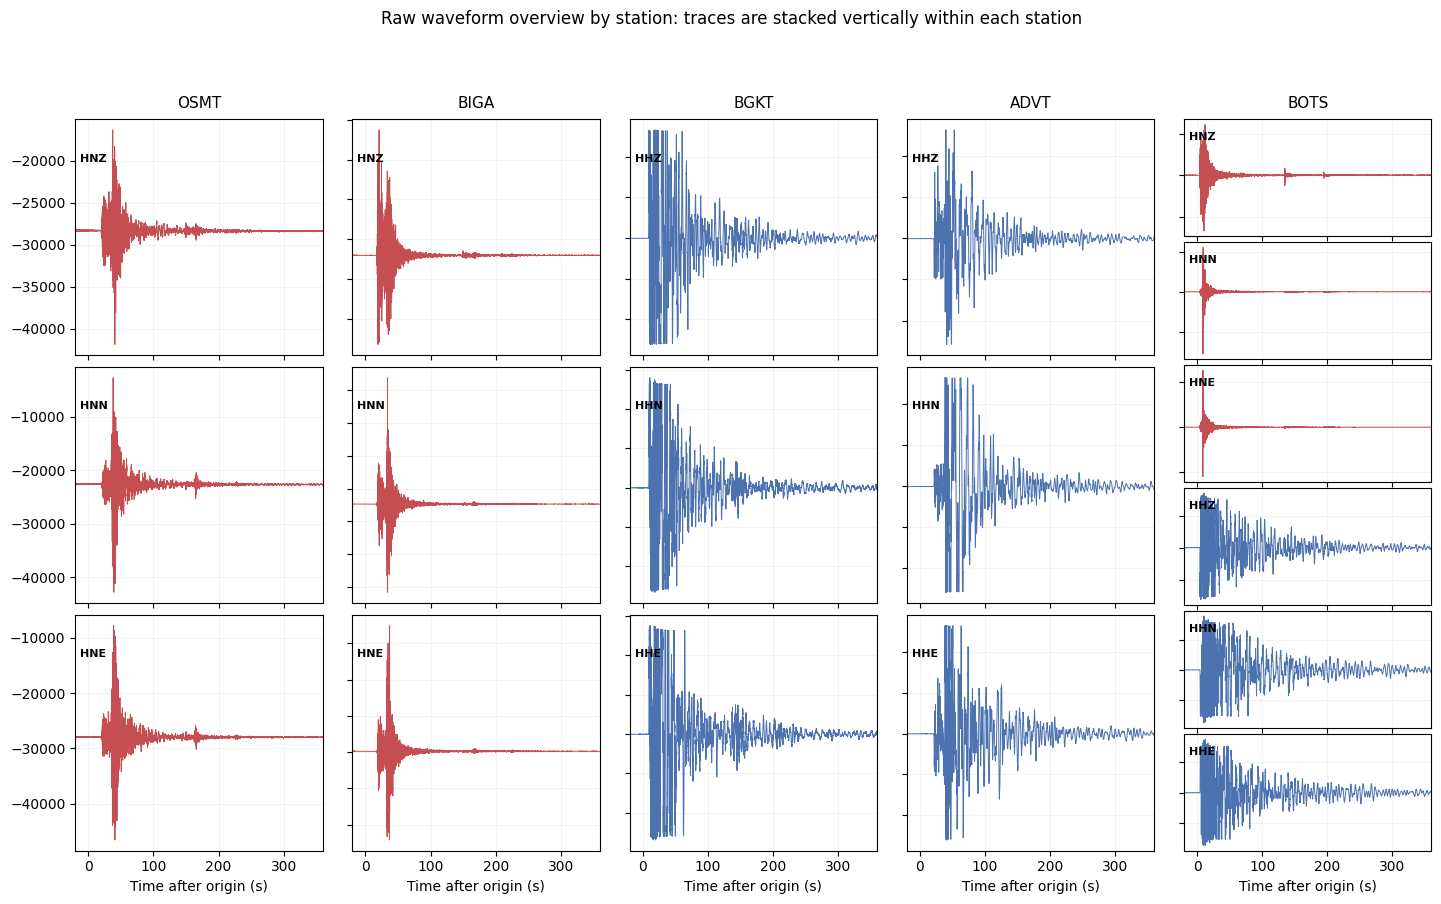

In [9]:
def trace_sort_key(trace):
    # Group by instrument family first and then by component so that
    # HN and HH channels stay visually organized within one station.
    prefix = trace.stats.channel[:2]
    component = trace.stats.channel[2]
    return (
        FAMILY_ORDER.get(prefix, 9),
        COMPONENT_ORDER.get(component, 9),
        trace.stats.channel,
    )


fig = plt.figure(figsize=(17.5, 9.5))
outer = GridSpec(1, len(STATION_ORDER), figure=fig, wspace=0.12)
family_colors = {"HN": "#c44e52", "HH": "#4c72b0"}

for col, station in enumerate(STATION_ORDER):
    traces = sorted(st_plot.select(station=station), key=trace_sort_key)
    inner = GridSpecFromSubplotSpec(len(traces), 1, subplot_spec=outer[col], hspace=0.05)

    for row, trace in enumerate(traces):
        ax = fig.add_subplot(inner[row, 0])
        times = trace.times(reftime=origin_time)

        ax.plot(times, trace.data, color=family_colors.get(trace.stats.channel[:2], "0.2"), lw=0.7)
        ax.text(0.02, 0.82, trace.stats.channel, transform=ax.transAxes, fontsize=8, fontweight="bold")
        ax.grid(alpha=0.15)
        ax.set_xlim(-20, 360)

        if row == 0:
            ax.set_title(station, fontsize=11, pad=8)

        if row < len(traces) - 1:
            ax.set_xticklabels([])
        else:
            ax.set_xlabel("Time after origin (s)")

        if col > 0:
            ax.set_yticklabels([])

fig.suptitle("Raw waveform overview by station: traces are stacked vertically within each station", y=0.995)
plt.show()


---

## **Instrument types and why we mainly continue with `HN*`**

FDSN channel codes are already informative. A three-character seismic channel such as `HNZ` or `HHN` contains:

- a **band code**,
- a **source code**,
- a **subsource / orientation code**.

In the present notebook, the most important distinction is the **second character**:

- `H` in `HH*` means **high-gain seismometer**,
- `N` in `HN*` means **accelerometer**.

The broader point is that the channel family already hints at the **dynamic range** and the kind of motion the instrument is best suited for.


| Example family | Band-code impression | Source code | Typical instrument class | Typical use |
|---|---|---|---|---|
| `HHZ` | `H` = high sample rate broadband range | `H` = high-gain seismometer | sensitive velocity-style seismic sensor | weak to moderate ground motion, detailed phase work |
| `BHZ` | `B` = broadband sample range | `H` = high-gain seismometer | standard broadband seismometer | regional and teleseismic monitoring |
| `EHZ` | `E` = short-period high sample range | `H` = high-gain seismometer | short-period seismometer | local seismicity, higher-frequency signals |
| `LHZ` | `L` = low sample rate long-period range | `H` = high-gain seismometer | long-period seismometer | long-period and teleseismic studies |
| `HNZ` | `H` = high sample rate broadband range | `N` = accelerometer | strong-motion accelerometer | large nearby shaking |

In this practical, the key contrast is therefore **high-gain seismometer (`HH*`) versus accelerometer (`HN*`)**.


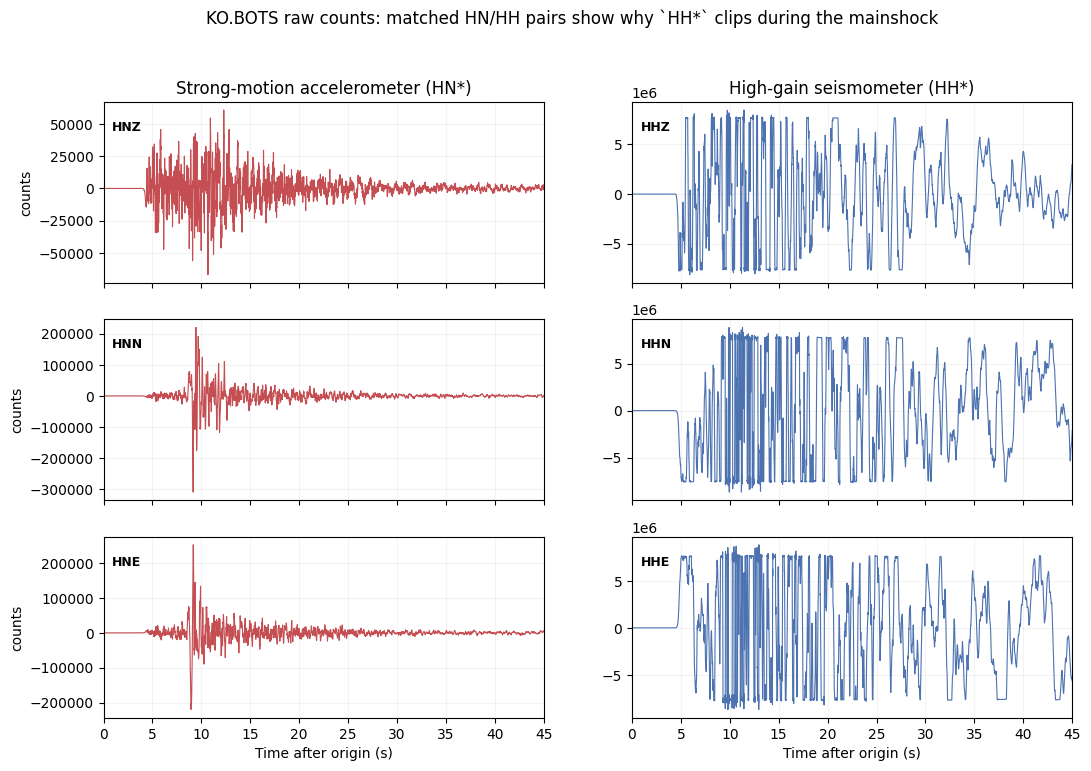

In [10]:
bots_zoom = st_plot.select(station="BOTS").copy()
bots_zoom.trim(origin_time - 2.0, origin_time + 45.0, pad=True, fill_value=np.nan)

fig, axes = plt.subplots(3, 2, figsize=(12.5, 8), sharex=True)
pair_colors = {"HN": "#c44e52", "HH": "#4c72b0"}

for row, component in enumerate(["Z", "N", "E"]):
    trace_hn = bots_zoom.select(channel="HN" + component)[0]
    trace_hh = bots_zoom.select(channel="HH" + component)[0]

    for col, trace in enumerate([trace_hn, trace_hh]):
        prefix = trace.stats.channel[:2]
        times = trace.times(reftime=origin_time)
        axes[row, col].plot(times, trace.data, color=pair_colors[prefix], lw=0.8)
        axes[row, col].grid(alpha=0.15)
        axes[row, col].set_xlim(0, 45)
        axes[row, col].text(0.02, 0.84, trace.stats.channel, transform=axes[row, col].transAxes, fontsize=9, fontweight="bold")

        if row == 0:
            title = "Strong-motion accelerometer (HN*)" if col == 0 else "High-gain seismometer (HH*)"
            axes[row, col].set_title(title)

        if col == 0:
            axes[row, col].set_ylabel("counts")

axes[-1, 0].set_xlabel("Time after origin (s)")
axes[-1, 1].set_xlabel("Time after origin (s)")
fig.suptitle("KO.BOTS raw counts: matched HN/HH pairs show why `HH*` clips during the mainshock", y=0.995)
plt.show()



### **Question 7.1**

1. Describe one or two visual features in the `BOTS` comparison that show `HH*` is unusable for reliable mainshock amplitude analysis.
2. If only `HH*` were available, which later processing steps would still be meaningful, and which amplitude-based conclusions would become questionable?


---

## **Focus switch: from network overview to one station for the processing workflow**

From here on, we simplify deliberately and work mainly with **`KO.OSMT`**. That gives us a good 3-C record for the core processing steps, while still keeping the full station set available for the arrival-time section later on.


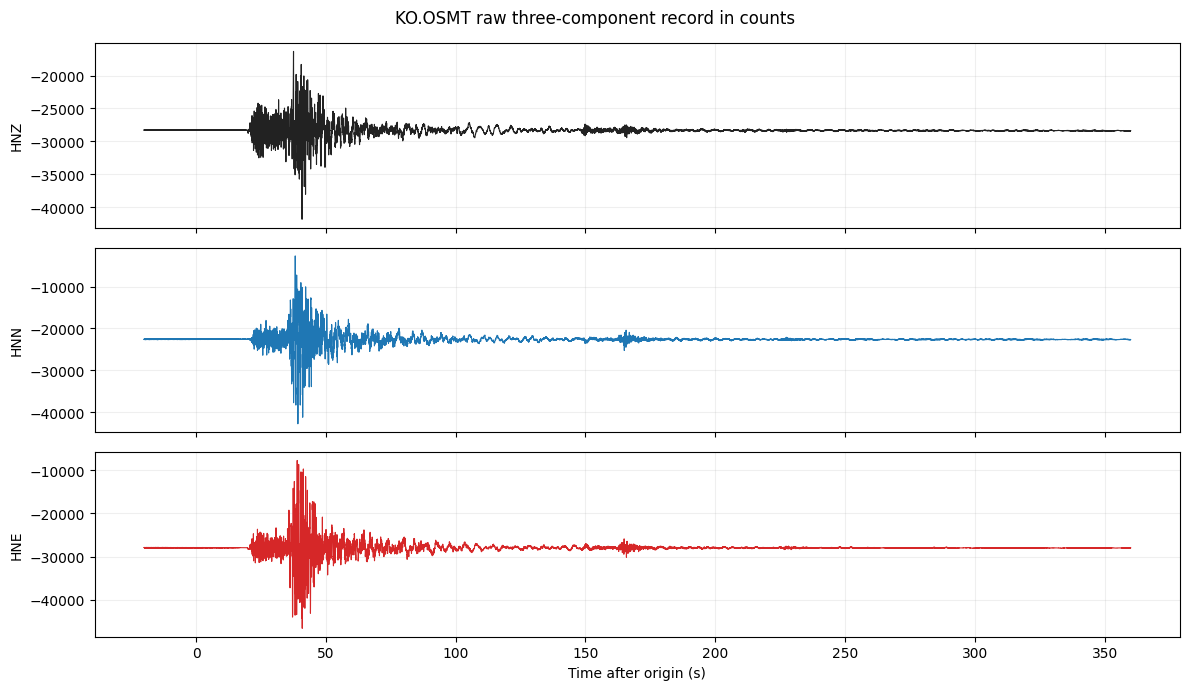

In [11]:
st_osmt_plot = st_plot.select(station="OSMT").copy()
st_osmt_proc = st_proc.select(station="OSMT").copy()

def prepare_trace(trace, remove_mean=True, remove_linear=True):
    # Always work on a copy so that raw data stay available.
    tr = trace.copy()

    # Convert to float immediately. This avoids integer overflow and makes
    # later filtering / RMS / FFT operations numerically safer.
    tr.data = tr.data.astype(float)

    # The workflow calls first for demeaning and then for removing a
    # linear trend. We keep the two steps explicit so the processing
    # logic stays visible rather than hiding it in one opaque command.
    if remove_mean:
        tr.detrend("demean")
    if remove_linear:
        tr.detrend("linear")

    return tr


fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True)
component_colors = {"HNZ": "#222222", "HNN": "#1f77b4", "HNE": "#d62728"}

for ax, channel in zip(axes, ["HNZ", "HNN", "HNE"]):
    trace = st_osmt_plot.select(channel=channel)[0]
    ax.plot(trace.times(reftime=origin_time), trace.data, color=component_colors[channel], lw=0.8)
    ax.set_ylabel(channel)
    ax.grid(alpha=0.2)

axes[-1].set_xlabel("Time after origin (s)")
fig.suptitle("KO.OSMT raw three-component record in counts")
plt.tight_layout()
plt.show()


---

## **RMS amplitude through time**

A moving RMS is an **energy-envelope diagnostic**, not a phase picker. In continuous form, a windowed RMS of length $\tau$ can be written as

$$
\mathrm{RMS}_{\tau}(t) =
\sqrt{\frac{1}{\tau}\int_{t-\tau/2}^{t+\tau/2} x^2(u)\,\mathrm{d}u},
$$

and in discrete form as

$$
\mathrm{RMS}(t_j) = \sqrt{\frac{1}{N}\sum_{i=1}^{N} x_i^2}.
$$

Here:

- $x(u)$ or $x_i$ is the waveform amplitude,
- $\tau$ is the moving-window length in seconds,
- $N$ is the number of samples inside the window.

Because the amplitudes are squared before averaging, polarity is removed and sustained energy is emphasized. RMS is therefore closer to a **windowed amplitude-energy measure** than to an onset detector.

That makes RMS useful for:

- comparing noise, P, and S windows quantitatively,
- following how energy redistributes between components,
- checking whether an apparently strong phase is truly energetic or only visually sharp.

It also has two important limitations:

- the moving window smears abrupt onsets in time,
- the result depends on the chosen window length.

So RMS is well suited to **windowed energy comparison** but not to precise picking.

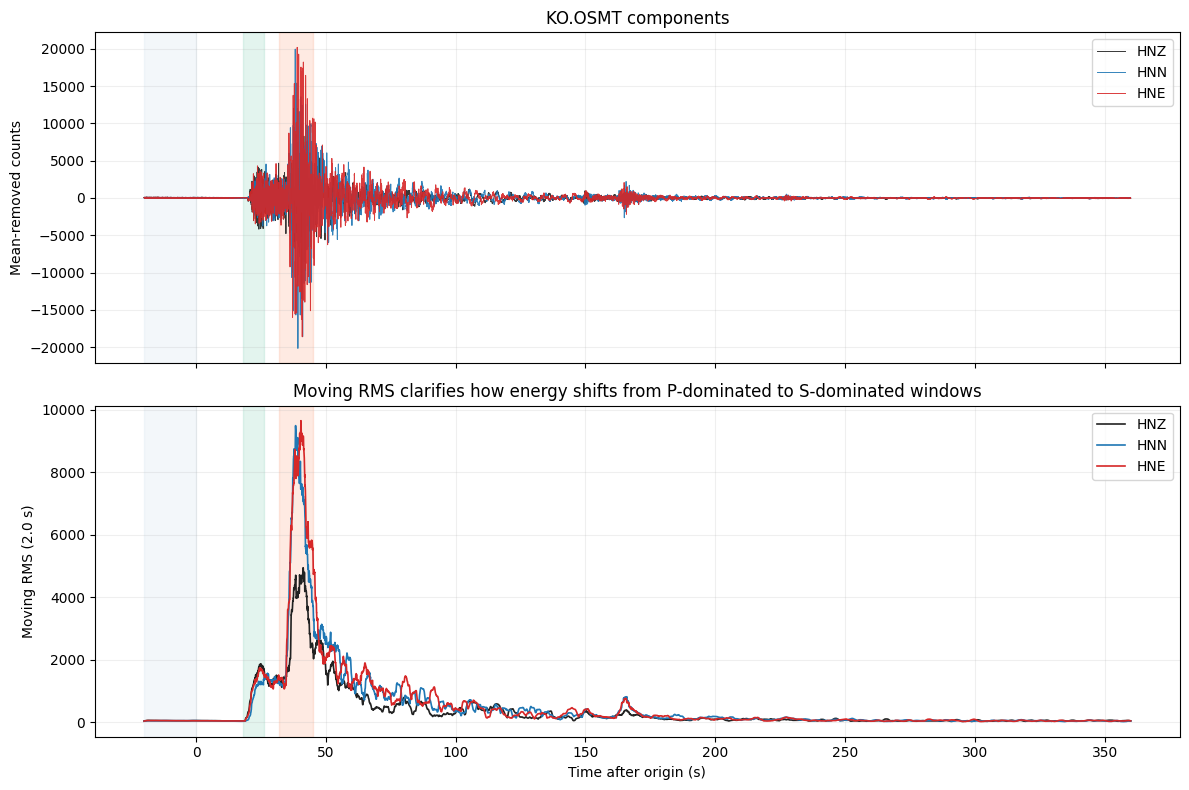

In [12]:
def moving_rms(data, window_samples):
    # Convert to float so that squaring the data does not overflow.
    data = np.asarray(data, dtype=float)

    # RMS is the square root of a moving mean-square quantity.
    squared = data ** 2
    kernel = np.ones(window_samples) / window_samples
    mean_squared = np.convolve(squared, kernel, mode="same")
    return np.sqrt(mean_squared)


rms_window_s = 2.0
rms_window_samples = int(rms_window_s * st_osmt_proc[0].stats.sampling_rate)

noise_window = (-20.0, 0.0)
p_window = (18.0, 26.0)
s_window = (32.0, 45.0)

osmt_rms_stream = st_osmt_proc.copy()
for trace in osmt_rms_stream:
    trace.data = trace.data.astype(float)
    trace.data -= np.mean(trace.data)

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

for channel in ["HNZ", "HNN", "HNE"]:
    trace = osmt_rms_stream.select(channel=channel)[0]
    times = trace.times(reftime=origin_time)
    axes[0].plot(times, trace.data, color=component_colors[channel], lw=0.7, label=channel, alpha=0.9)
    axes[1].plot(times, moving_rms(trace.data, rms_window_samples), color=component_colors[channel], lw=1.2, label=channel)

for ax in axes:
    ax.axvspan(*noise_window, color="#b3cde3", alpha=0.15)
    ax.axvspan(*p_window, color="#66c2a5", alpha=0.18)
    ax.axvspan(*s_window, color="#fc8d62", alpha=0.18)
    ax.grid(alpha=0.2)
    ax.legend(loc="upper right")

axes[0].set_ylabel("Mean-removed counts")
axes[0].set_title("KO.OSMT components")
axes[1].set_ylabel(f"Moving RMS ({rms_window_s:.1f} s)")
axes[1].set_title("Moving RMS clarifies how energy shifts from P-dominated to S-dominated windows")
axes[1].set_xlabel("Time after origin (s)")
plt.tight_layout()
plt.show()


In [ ]:
rms_rows = []
for channel in ["HNZ", "HNN", "HNE"]:
    trace = osmt_rms_stream.select(channel=channel)[0]
    times = trace.times(reftime=origin_time)

    row = {"channel": channel}
    for label, (t0, t1) in {
        "noise_rms": noise_window,
        "P_rms": p_window,
        "S_rms": s_window,
    }.items():
        mask = (times >= t0) & (times < t1)
        row[label] = np.sqrt(np.mean(trace.data[mask] ** 2))
    rms_rows.append(row)

rms_table = pd.DataFrame(rms_rows)
display(rms_table)


### **Question 8.1**

1. Calculate the P/noise and S/noise RMS amplification factors for `HNZ`, `HNN`, and `HNE`. Which component would you choose for first-arrival detection, and which for S-energy characterization?
2. Estimate the horizontal-vector RMS,
   $R_H = \sqrt{R_N^2 + R_E^2}$,
   in the P and S windows. By what factor does $R_H / R_Z$ change from the P window to the S window?

---

## **Detrending: `demean` first, then `linear`**

Before filtering, we remove low-order baseline terms from the **full** record, where

- `demean` removes the constant term,
- `linear` removes the best-fitting first-order trend.

We do this on the full `[-20 s, +360 s]` window and **without tapering** at this stage, because the aim of this section is to isolate the effect of baseline correction before any additional operation reshapes the trace.


In [ ]:
raw_hnz = st_osmt_proc.select(channel="HNZ")[0].copy()
demean_hnz = prepare_trace(raw_hnz, remove_mean=True, remove_linear=False)
detrended_hnz = prepare_trace(raw_hnz, remove_mean=True, remove_linear=True)

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
for ax, trace, title in zip(
    axes,
    [raw_hnz, demean_hnz, detrended_hnz],
    ["Raw HNZ", "After demean", "After demean + linear detrend"],
):
    ax.plot(trace.times(reftime=origin_time), trace.data, color="#222222", lw=0.8)
    ax.set_title(title)
    ax.grid(alpha=0.2)

axes[-1].set_xlabel("Time after origin (s)")
plt.tight_layout()
plt.show()


In [ ]:
st_osmt_detrended = st_osmt_proc.copy()
for index, trace in enumerate(st_osmt_detrended):
    st_osmt_detrended[index] = prepare_trace(trace, remove_mean=True, remove_linear=True)

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
for ax, channel in zip(axes, ["HNZ", "HNN", "HNE"]):
    trace = st_osmt_detrended.select(channel=channel)[0]
    ax.plot(trace.times(reftime=origin_time), trace.data, color=component_colors[channel], lw=0.8)
    ax.set_title(channel)
    ax.set_xlabel("Time after origin (s)")
    ax.grid(alpha=0.2)

axes[0].set_ylabel("Detrended counts")
fig.suptitle("KO.OSMT components after full-window detrending and before taper / filtering", y=1.03)
plt.tight_layout()
plt.show()


### **Question 9.1**

1. Why is detrending placed before filtering in a defensible processing chain on a finite record?
2. What is clearly visually changing in the plots?

---

## **Filtering: high-pass, low-pass, or band-pass?**

Filtering should be treated as a **signal-analysis decision**, not as a cosmetic step. In the frequency domain we can write

$$
Y(f) = H(f)\,X(f)
$$

with:

- $X(f)$ the input spectrum,
- $H(f)$ the filter transfer function,
- $Y(f)$ the output spectrum.

The filter is therefore a frequency-dependent weighting. Frequencies passed by $H(f)$ remain visible; frequencies strongly attenuated by $H(f)$ are suppressed. This is why filtering can improve interpretability, but it can also remove physically important information if the chosen band is too narrow or misplaced.

For earthquake data, the choice of passband depends on the actual task:

- **high-pass** filtering suppresses long-period baseline and very slow motion,
- **low-pass** filtering suppresses rapidly varying high-frequency content,
- **band-pass** filtering enforces both a low- and high-frequency decision at the same time.

In practice, the lower corner mainly controls how much slow baseline, coda, and long-period contamination remain, whereas the upper corner controls how much short-period noise and very sharp fluctuations survive. A defensible filter must therefore be justified against both the signal and the noise.

A defensible filter should improve the contrast between:

- signal windows and neighboring noise windows,
- physically interpretable arrivals and incoherent fluctuations,
- the specific phase or event you want to study.

In this section we therefore ask two different questions:

1. Which filter is best for the **main event**?
2. Which filter is best for **weaker-event detection later in the same record**?

In [ ]:
def make_linked_float_control(description, value, min_value, max_value, step, readout_format=".2f"):
    # Pair a slider with a manual numeric box so values can be changed
    # quickly or entered exactly.
    slider = widgets.FloatSlider(
        value=value,
        min=min_value,
        max=max_value,
        step=step,
        description=description,
        readout_format=readout_format,
        style={"description_width": "80px"},
        layout=widgets.Layout(width="420px"),
    )
    text = widgets.BoundedFloatText(
        value=value,
        min=min_value,
        max=max_value,
        step=step,
        layout=widgets.Layout(width="120px"),
    )
    widgets.jslink((slider, "value"), (text, "value"))
    return slider, text, widgets.HBox([slider, text])


def apply_filter_mode(trace, filter_mode, freqmin, freqmax, corners=4, zerophase=True):
    # Always start from a fresh copy so that repeated widget calls do not
    # stack filters on top of each other.
    tr = trace.copy()

    if filter_mode == "raw":
        return tr
    if filter_mode == "highpass":
        tr.filter("highpass", freq=freqmin, corners=corners, zerophase=zerophase)
        return tr
    if filter_mode == "lowpass":
        tr.filter("lowpass", freq=freqmax, corners=corners, zerophase=zerophase)
        return tr
    if filter_mode == "bandpass":
        if freqmax <= freqmin:
            raise ValueError("For a band-pass filter, freqmax must be larger than freqmin.")
        tr.filter(
            "bandpass",
            freqmin=freqmin,
            freqmax=freqmax,
            corners=corners,
            zerophase=zerophase,
        )
        return tr

    raise ValueError(f"Unknown filter mode: {filter_mode}")


base_osmt_traces = {
    channel: prepare_trace(st_osmt_proc.select(channel=channel)[0], remove_mean=True, remove_linear=True)
    for channel in ["HNZ", "HNN", "HNE"]
}


In [ ]:
filter_candidates = [
    {"label": "Raw", "mode": "raw", "freqmin": 1.0, "freqmax": 10.0},
    {"label": "High-pass 1 Hz", "mode": "highpass", "freqmin": 1.0, "freqmax": 10.0},
    {"label": "Low-pass 8 Hz", "mode": "lowpass", "freqmin": 1.0, "freqmax": 8.0},
    {"label": "Band-pass 0.2-10 Hz", "mode": "bandpass", "freqmin": 0.2, "freqmax": 10.0},
    {"label": "Band-pass 1-10 Hz", "mode": "bandpass", "freqmin": 1.0, "freqmax": 10.0},
    {"label": "Band-pass 2-12 Hz", "mode": "bandpass", "freqmin": 2.0, "freqmax": 12.0},
    {"label": "Band-pass 3-12 Hz", "mode": "bandpass", "freqmin": 3.0, "freqmax": 12.0},
]

filter_main_window = (12.0, 60.0)
filter_late_window = (140.0, 240.0)
filter_noise_window = (130.0, 145.0)
filter_main_s_window = (32.0, 45.0)
filter_late_windows = {
    "later1": (148.0, 166.5),
    "later2": (208.0, 226.5),
}

fig, axes = plt.subplots(len(filter_candidates), 2, figsize=(13, 2.15 * len(filter_candidates)), sharex="col")
for row, candidate in enumerate(filter_candidates):
    trace = apply_filter_mode(
        base_osmt_traces["HNZ"],
        candidate["mode"],
        candidate["freqmin"],
        candidate["freqmax"],
        corners=4,
        zerophase=True,
    )
    times = trace.times(reftime=origin_time)

    main_mask = (times >= filter_main_window[0]) & (times <= filter_main_window[1])
    late_mask = (times >= filter_late_window[0]) & (times <= filter_late_window[1])

    axes[row, 0].plot(times[main_mask], trace.data[main_mask], color="#222222", lw=0.8)
    axes[row, 1].plot(times[late_mask], trace.data[late_mask], color="#222222", lw=0.8)

    axes[row, 0].axvspan(18.0, 26.0, color="#66c2a5", alpha=0.16)
    axes[row, 0].axvspan(32.0, 45.0, color="#fc8d62", alpha=0.16)
    axes[row, 1].axvline(148.189, color="tab:green", ls="--", lw=0.9, alpha=0.7)
    axes[row, 1].axvline(162.679, color="tab:red", ls="--", lw=0.9, alpha=0.7)
    axes[row, 1].axvline(209.419, color="tab:green", ls="--", lw=0.9, alpha=0.7)
    axes[row, 1].axvline(225.129, color="tab:red", ls="--", lw=0.9, alpha=0.7)

    axes[row, 0].text(0.01, 0.82, candidate["label"], transform=axes[row, 0].transAxes, fontsize=9, fontweight="bold")
    axes[row, 0].grid(alpha=0.2)
    axes[row, 1].grid(alpha=0.2)

axes[0, 0].set_title("Main event window | HNZ")
axes[0, 1].set_title("Later-event window | HNZ")
axes[-1, 0].set_xlabel("Time after origin (s)")
axes[-1, 1].set_xlabel("Time after origin (s)")
for ax in axes[:, 0]:
    ax.set_ylabel("Filtered counts")
plt.tight_layout()
plt.show()

### **Question 10.1**

1. Is the same passband optimal for both tasks? Explain briefly what is gained for weak-event detection and what is lost for general waveform interpretation when the passband becomes too narrow or too high-frequency.
3. `Band-pass 3-12 Hz` often improves the visibility of the later weak packets. Why is it still a risky default for routine processing of the whole record?
4. Which of the two later events is less robust under filter changes, and what does that imply for your confidence in interpreting it?


In [ ]:
later_event_windows = {
    "Event 1": (140.0, 176.0),
    "Event 2": (200.0, 240.0),
}

chosen_band = (1.0, 10.0)
later_band_stream = {}
for channel in ["HNZ", "HNN", "HNE"]:
    later_band_stream[channel] = apply_filter_mode(base_osmt_traces[channel], "bandpass", chosen_band[0], chosen_band[1], corners=4)

fig, axes = plt.subplots(3, 2, figsize=(12, 8), sharey="row")
for col, (event_name, (t0, t1)) in enumerate(later_event_windows.items()):
    for row, channel in enumerate(["HNZ", "HNN", "HNE"]):
        trace = later_band_stream[channel]
        times = trace.times(reftime=origin_time)
        mask = (times >= t0) & (times <= t1)
        axes[row, col].plot(times[mask], trace.data[mask], color=component_colors[channel], lw=0.9)
        axes[row, col].grid(alpha=0.2)
        axes[row, col].set_title(f"{event_name} | {channel}")
        axes[row, col].axvline(148.189 if event_name == "Event 1" else 209.419, color="tab:green", ls="--", lw=0.9, alpha=0.6)
        axes[row, col].axvline(162.679 if event_name == "Event 1" else 225.129, color="tab:red", ls="--", lw=0.9, alpha=0.6)

axes[-1, 0].set_xlabel("Time after origin (s)")
axes[-1, 1].set_xlabel("Time after origin (s)")
axes[0, 0].set_ylabel("Filtered counts")
axes[1, 0].set_ylabel("Filtered counts")
axes[2, 0].set_ylabel("Filtered counts")
fig.suptitle("Later weak events after band-pass filtering (1.0-10.0 Hz)", y=1.02)
plt.tight_layout()
plt.show()


In [ ]:
later_event_measurements = []
later_h_trace = later_band_stream["HNN"].copy()
later_h_trace.data = np.sqrt(later_band_stream["HNN"].data.astype(float) ** 2 + later_band_stream["HNE"].data.astype(float) ** 2)
later_h_times = later_h_trace.times(reftime=origin_time)

for label, p_time, s_time, amplitude_window in [
    ("Main event", 19.779, 36.029, (18.0, 45.0)),
    ("Later event 1", 148.189, 162.679, later_event_windows["Event 1"]),
    ("Later event 2", 209.419, 225.129, later_event_windows["Event 2"]),
]:
    sp_time = s_time - p_time

    amp_mask = (later_h_times >= amplitude_window[0]) & (later_h_times <= amplitude_window[1])
    peak_index = np.argmax(np.abs(later_h_trace.data[amp_mask]))
    peak_amplitude = float(np.abs(later_h_trace.data[amp_mask])[peak_index])
    peak_time = float(later_h_times[amp_mask][peak_index])

    later_event_measurements.append(
        {
            "event": label,
            "P_time_s": p_time,
            "S_time_s": s_time,
            "S_minus_P_s": sp_time,
            "peak_horizontal_amplitude_counts": peak_amplitude,
            "time_of_peak_amplitude_s": peak_time,
        }
    )

later_event_table = pd.DataFrame(later_event_measurements)
display(later_event_table.round(3))

### **Question 11.1**

1. Compute `S-P` for all three events and use
   $R \approx (t_S - t_P)/(1/v_S - 1/v_P)$, with $v_P \approx 6.0\,\mathrm{km/s}$ and $v_S \approx 3.5\,\mathrm{km/s}$
   to estimate the source-receiver distance for each event. Are the later events consistent with the same distance class as the mainshock?
2. Use the peak horizontal amplitudes and assume the events are recorded at approximately the same station distance. Estimate the magnitudes of the two later events from
   $\Delta M = \log_{10}(A_{\mathrm{event}} / A_{\mathrm{main}})$
   relative to the `Mw 6.2` main event.
3. Based on both the `S-P` comparison and the amplitude scaling, argue whether the two later signals are plausible aftershocks or whether another explanation is still possible.


---

## **Fourier spectrum and spectrogram**

The Fourier spectrum and the spectrogram answer **different** questions, and this is exactly why both are needed in seismology.

- The amplitude spectrum tells us **which frequencies are present overall** in the analyzed window.
- The spectrogram tells us **when** those frequencies are strong.

For a non-stationary earthquake record, the distinction matters. A whole-record spectrum can tell us that 4 Hz energy exists, but it cannot tell us whether that 4 Hz energy belongs to the P onset, the S coda, or one of the later weak events.

The Fourier transform also contains **phase information**, but in this section we inspect mainly the amplitude spectrum. That means we intentionally keep information about “how much of each frequency is present” while setting aside the phase angles that would be needed to reconstruct timing exactly from the spectrum alone.

For a discrete real-valued trace, a simple one-sided amplitude spectrum is:

$$
A(f_k) = \frac{2}{N}\left|X_k\right|
$$

where:

- $A(f_k)$ is the one-sided amplitude at frequency bin $f_k$,
- $N$ is the number of time samples in the trace,
- $X_k$ is the discrete Fourier transform coefficient at index $k$,
- $f_k$ is the frequency corresponding to that coefficient.

The Fourier coefficients themselves come from

$$
X_k = \sum_{n=0}^{N-1} x_n\,e^{-i 2\pi kn/N},
$$

where $x_n$ is the sampled waveform value at index $n$ and $k$ indexes the frequency bin. So the amplitude spectrum is derived from the magnitude of those complex coefficients.

A spectrogram is based on a short-time Fourier transform (STFT):

$$
X(\tau, f) = \int x(t)\,w(t-\tau)\,e^{-i 2\pi f t}\,\mathrm{d}t
$$

with:

- $x(t)$ as the waveform in the time domain,
- $w(t-\tau)$ as the analysis window centered at time $\tau$,
- $f$ as frequency,
- $X(\tau, f)$ as the local time-frequency representation.

This immediately creates the central trade-off:

- shorter windows improve **time localization**,
- longer windows improve **frequency resolution**.


**Interactive task: spectrogram**

Adjust the values below; the plot updates automatically.

1. Start with `HNZ`, `bandpass`, `1-10 Hz`, and a `4 s` window.
2. Shorten the window and note the improvement in timing versus the loss in frequency resolution.
3. Lengthen the window and check how weak late events blur less or more clearly in frequency.
4. Compare `HNZ` with `HNN`/`HNE` and ask whether the same frequency content is equally important on every component.


In [ ]:
def amplitude_spectrum(trace):
    # Compute the one-sided amplitude spectrum for a real-valued trace.
    data = np.asarray(trace.data, dtype=float)
    delta = trace.stats.delta
    npts = len(data)

    frequencies = np.fft.rfftfreq(npts, d=delta)
    spectrum = np.fft.rfft(data)
    amplitudes = 2.0 * np.abs(spectrum) / npts

    # Correct the DC term and the Nyquist term so that the one-sided
    # amplitude scaling is physically meaningful.
    amplitudes[0] /= 2.0
    if npts % 2 == 0:
        amplitudes[-1] /= 2.0

    return frequencies, amplitudes


spec_channel_widget = widgets.Dropdown(
    options=["HNZ", "HNN", "HNE"],
    value="HNZ",
    description="channel",
    style={"description_width": "80px"},
)
spec_mode_widget = widgets.Dropdown(
    options=["raw", "highpass", "lowpass", "bandpass"],
    value="bandpass",
    description="mode",
    style={"description_width": "80px"},
)
spec_fmin_widget = widgets.BoundedFloatText(
    value=1.0,
    min=0.1,
    max=8.0,
    step=0.1,
    description="fmin (Hz)",
    style={"description_width": "80px"},
)
spec_fmax_widget = widgets.BoundedFloatText(
    value=10.0,
    min=1.0,
    max=20.0,
    step=0.1,
    description="fmax (Hz)",
    style={"description_width": "80px"},
)
spec_window_widget = widgets.BoundedFloatText(
    value=4.0,
    min=1.0,
    max=12.0,
    step=0.5,
    description="window (s)",
    style={"description_width": "80px"},
)
spec_maxhz_widget = widgets.BoundedFloatText(
    value=15.0,
    min=5.0,
    max=25.0,
    step=1.0,
    description="max Hz",
    style={"description_width": "80px"},
)
spec_overlap_widget = widgets.BoundedFloatText(
    value=0.85,
    min=0.2,
    max=0.95,
    step=0.05,
    description="overlap",
    style={"description_width": "80px"},
)

def spectrogram_explorer(channel="HNZ", filter_mode="bandpass", freqmin=1.0, freqmax=10.0, window_length_s=4.0, max_frequency=15.0, overlap=0.85):
    trace = apply_filter_mode(base_osmt_traces[channel], filter_mode, freqmin, freqmax)
    fs = trace.stats.sampling_rate
    nperseg = max(64, int(window_length_s * fs))
    noverlap = int(overlap * nperseg)

    frequencies, times, spec = scipy_spectrogram(
        trace.data.astype(float),
        fs=fs,
        nperseg=nperseg,
        noverlap=noverlap,
        scaling="density",
        mode="magnitude",
    )

    fig, ax = plt.subplots(figsize=(11, 5))
    mesh = ax.pcolormesh(
        times - PRE_EVENT_S,
        frequencies,
        20 * np.log10(spec + 1e-12),
        shading="auto",
        cmap="magma",
    )
    ax.set_ylim(0, max_frequency)
    ax.set_ylabel("Frequency (Hz)")
    ax.set_xlabel("Time after origin (s)")
    ax.set_title(f"{channel} spectrogram after {filter_mode}")
    ax.grid(alpha=0.1)
    fig.colorbar(mesh, ax=ax, label="Amplitude (dB)")
    plt.tight_layout()
    plt.show()
    plt.close(fig)


spectrogram_controls = {
    "channel": spec_channel_widget,
    "filter_mode": spec_mode_widget,
    "freqmin": spec_fmin_widget,
    "freqmax": spec_fmax_widget,
    "window_length_s": spec_window_widget,
    "max_frequency": spec_maxhz_widget,
    "overlap": spec_overlap_widget,
}
spectrogram_output = widgets.interactive_output(spectrogram_explorer, spectrogram_controls)

display(
    widgets.VBox(
        [
            widgets.HBox([spec_channel_widget, spec_mode_widget]),
            widgets.HBox([spec_fmin_widget, spec_fmax_widget]),
            widgets.HBox([spec_window_widget, spec_maxhz_widget, spec_overlap_widget]),
            spectrogram_output,
        ]
    )
)


---

## **Instrument response: native output units**

Response removal is a **deconvolution** problem. In the frequency domain we write

$$
U_{\mathrm{obs}}(\omega) = I(\omega)\,G(\omega)
$$

so that the desired ground motion is obtained by dividing out the instrument response. This inversion must be stabilized, because frequencies where the instrument response is very small can amplify noise strongly.

For the practical we keep the response-removal example on **OSMT only**. OSMT provides `HN*` strong-motion channels, so this section focuses on the accelerometer case and asks which output quantity is most native for that station.

The same logic generalizes to other channel families: before deciding whether `ACC`, `VEL`, or `DISP` is the most natural target, the first thing to inspect is the response metadata, especially the instrument input units and the sensor description.

In [ ]:
response_prefilt = [0.05, 0.10, 20.0, 30.0]
response_examples = [("OSMT", "HNZ")]

response_metadata_rows = []
for network in inventory:
    for station in network:
        if station.code != "OSMT":
            continue
        for channel in station:
            if channel.code[:2] != "HN":
                continue
            if channel.code[2] not in {"Z", "N", "E"}:
                continue
            sensitivity = channel.response.instrument_sensitivity
            response_metadata_rows.append(
                {
                    "station": station.code,
                    "channel": channel.code,
                    "sensor": getattr(channel.sensor, "description", "unknown"),
                    "input_units": sensitivity.input_units,
                    "output_units": sensitivity.output_units,
                }
            )

response_metadata_table = pd.DataFrame(response_metadata_rows).sort_values(["station", "channel"]).reset_index(drop=True)
display(response_metadata_table)

In [ ]:
fig, axes = plt.subplots(len(response_examples), 3, figsize=(14, 6.5), sharex=True)
if len(response_examples) == 1:
    axes = np.array([axes])

for row, (station, channel) in enumerate(response_examples):
    base_trace = prepare_trace(st_proc.select(station=station, channel=channel)[0], remove_mean=True, remove_linear=True)

    for col, output_unit in enumerate(["ACC", "VEL", "DISP"]):
        trace = base_trace.copy()
        trace.remove_response(
            inventory=inventory,
            output=output_unit,
            pre_filt=response_prefilt,
            water_level=None,
        )
        times = trace.times(reftime=origin_time)
        mask = (times >= -20.0) & (times <= 80.0)
        pre_event = trace.data[(times >= -20.0) & (times < 0.0)]
        main_event = trace.data[(times >= 18.0) & (times <= 45.0)]

        ax = axes[row, col]
        ax.plot(times[mask], trace.data[mask], color="#1f77b4", lw=0.8)
        ax.grid(alpha=0.2)
        ax.set_title(
            f"{station} {channel} -> {output_unit}\n"
            f"main peak={np.max(np.abs(main_event)):.3g}, pre-event std={np.std(pre_event):.3g}"
        )
        if col == 0:
            ax.set_ylabel(output_unit)

axes[-1, 0].set_xlabel("Time after origin (s)")
axes[-1, 1].set_xlabel("Time after origin (s)")
axes[-1, 2].set_xlabel("Time after origin (s)")
plt.tight_layout()
plt.show()

In [ ]:
response_summary_rows = []
for station, channel in response_examples:
    base_trace = prepare_trace(st_proc.select(station=station, channel=channel)[0], remove_mean=True, remove_linear=True)

    channel_metadata = response_metadata_table.loc[
        (response_metadata_table["station"] == station) & (response_metadata_table["channel"] == channel)
    ].iloc[0]

    for output_unit in ["ACC", "VEL", "DISP"]:
        trace = base_trace.copy()
        trace.remove_response(
            inventory=inventory,
            output=output_unit,
            pre_filt=response_prefilt,
            water_level=None,
        )
        times = trace.times(reftime=origin_time)
        pre_event = trace.data[(times >= -20.0) & (times < 0.0)]
        main_event = trace.data[(times >= 18.0) & (times <= 45.0)]
        response_summary_rows.append(
            {
                "station": station,
                "channel": channel,
                "metadata_input_units": channel_metadata["input_units"],
                "requested_output": output_unit,
                "main_peak_abs": float(np.max(np.abs(main_event))),
                "pre_event_std": float(np.std(pre_event)),
            }
        )

response_summary_table = pd.DataFrame(response_summary_rows)
display(response_summary_table.round(6))

### **Question 13.1**

1. Use the OSMT metadata table and the `HNZ` response-removal plots to identify the most native physical output for `HN*`. Why?
2. If you later worked with `HH*`, `BH*`, or `EH*` channels, which metadata field would you inspect first before deciding which output quantity is the most native?

---

## **Arrival detection and picking for the three OSMT events**

In the final part of the practical, we stay on one station (`OSMT`) and ask a simple question: can we recover **P and S picks for the main event plus the two later weak events** in one record?

We compare two complementary approaches that both start from the **unfiltered OSMT three-component stream**:

- `PhaseNet`, where you will change only the two threshold values,
- ObsPy `ar_pick`, where you can optionally test how sensitive the picker is to its control parameters.

The next code cell is only a **preparation cell**. It loads the stream, helper functions, and plotting settings.


In [ ]:
# Preparation cell for the arrival section.
# Students normally do not need to change anything here.

arrival_station = "OSMT"
arrival_prefix = "HN"
arrival_filter_band = (1.0, 10.0)
arrival_windows = {
    "Main event": {
        "plot_window": (10.0, 55.0),
        "P_window": (18.0, 24.0),
        "S_window": (33.0, 39.5),
    },
    "Later event 1": {
        "plot_window": (142.0, 170.0),
        "P_window": (146.0, 151.0),
        "S_window": (160.0, 165.5),
    },
    "Later event 2": {
        "plot_window": (203.0, 232.0),
        "P_window": (207.0, 212.0),
        "S_window": (223.0, 227.5),
    },
}

arrival_stream_raw = st_proc.select(station=arrival_station, channel=arrival_prefix + "?").copy()
arrival_stream_raw.sort(keys=["channel"])

arrival_stream_for_plot = arrival_stream_raw.copy()
for index, trace in enumerate(arrival_stream_for_plot):
    arrival_stream_for_plot[index] = prepare_trace(trace, remove_mean=True, remove_linear=True)
arrival_stream_for_plot.sort(keys=["channel"])

arrival_filtered_for_diagnostic = {
    channel: apply_filter_mode(
        arrival_stream_for_plot.select(channel=channel)[0],
        "bandpass",
        arrival_filter_band[0],
        arrival_filter_band[1],
    )
    for channel in [arrival_prefix + "Z", arrival_prefix + "N", arrival_prefix + "E"]
}
arrival_horizontal_diagnostic = arrival_filtered_for_diagnostic[arrival_prefix + "N"].copy()
arrival_horizontal_diagnostic.data = np.sqrt(
    arrival_filtered_for_diagnostic[arrival_prefix + "N"].data.astype(float) ** 2
    + arrival_filtered_for_diagnostic[arrival_prefix + "E"].data.astype(float) ** 2
)

full_times = arrival_stream_for_plot.select(channel=arrival_prefix + "Z")[0].times(reftime=origin_time)
plot_time_limits = (float(full_times.min()), float(full_times.max()))

component_offsets = {
    arrival_prefix + "Z": 2.5,
    arrival_prefix + "N": 1.3,
    arrival_prefix + "E": 0.1,
}
component_colors = {
    arrival_prefix + "Z": "#222222",
    arrival_prefix + "N": "#1f77b4",
    arrival_prefix + "E": "#d62728",
}

phase_window_lookup = {
    "P": [(event_name, spec["P_window"]) for event_name, spec in arrival_windows.items()],
    "S": [(event_name, spec["S_window"]) for event_name, spec in arrival_windows.items()],
}

phasenet = sbm.PhaseNet.from_pretrained("instance")
arrival_annotations = phasenet.annotate(arrival_stream_raw)
arrival_probability_traces = {trace.stats.channel: trace for trace in arrival_annotations}


def phase_pick_lists(p_threshold, s_threshold):
    classify_output = phasenet.classify_aggregate(
        arrival_annotations,
        {"P_threshold": p_threshold, "S_threshold": s_threshold},
    )
    p_picks = sorted(
        [
            {"time_s": pick.peak_time - origin_time, "probability": pick.peak_value}
            for pick in classify_output.picks
            if pick.phase == "P"
        ],
        key=lambda item: item["time_s"],
    )
    s_picks = sorted(
        [
            {"time_s": pick.peak_time - origin_time, "probability": pick.peak_value}
            for pick in classify_output.picks
            if pick.phase == "S"
        ],
        key=lambda item: item["time_s"],
    )
    return p_picks, s_picks


def first_pick_in_window(picks, time_window):
    for pick in picks:
        if time_window[0] <= pick["time_s"] <= time_window[1]:
            return pick
    return None


def count_extra_picks(picks, named_windows):
    return sum(
        1
        for pick in picks
        if not any(window[0] <= pick["time_s"] <= window[1] for _, window in named_windows)
    )


def scale_for_plot(data, percentile=99.5):
    amplitude_scale = np.nanpercentile(np.abs(data), percentile)
    if not np.isfinite(amplitude_scale) or amplitude_scale == 0.0:
        amplitude_scale = 1.0
    return amplitude_scale


def normalize_for_plot(data, percentile=99.5):
    return data / scale_for_plot(data, percentile=percentile)


def summarize_phase_picks(p_threshold, s_threshold):
    phase_picks, phase_s_picks = phase_pick_lists(p_threshold, s_threshold)

    phase_rows = []
    for event_name, spec in arrival_windows.items():
        phase_p = first_pick_in_window(phase_picks, spec["P_window"])
        phase_s = first_pick_in_window(phase_s_picks, spec["S_window"])
        phase_rows.append(
            {
                "event": event_name,
                "PhaseNet_P_found": phase_p is not None,
                "PhaseNet_P_s": phase_p["time_s"] if phase_p else np.nan,
                "PhaseNet_P_probability": phase_p["probability"] if phase_p else np.nan,
                "PhaseNet_S_found": phase_s is not None,
                "PhaseNet_S_s": phase_s["time_s"] if phase_s else np.nan,
                "PhaseNet_S_probability": phase_s["probability"] if phase_s else np.nan,
            }
        )

    phase_table = pd.DataFrame(phase_rows)
    events_with_both = int(phase_table[["PhaseNet_P_found", "PhaseNet_S_found"]].all(axis=1).sum())
    extra_phase_counts = {
        "P": count_extra_picks(phase_picks, phase_window_lookup["P"]),
        "S": count_extra_picks(phase_s_picks, phase_window_lookup["S"]),
    }

    return {
        "phase_picks": phase_picks,
        "phase_s_picks": phase_s_picks,
        "table": phase_table,
        "events_with_both": events_with_both,
        "extra_counts": extra_phase_counts,
    }


def plot_phase_overview(phase_result, p_threshold, s_threshold):
    phase_overview_text = (
        f"Current thresholds: P = {p_threshold:.2f}, S = {s_threshold:.2f}\n"
        f"Target events with both picks: {phase_result['events_with_both']} / {len(phase_result['table'])}\n"
        f"Extra picks outside target windows: P = {phase_result['extra_counts']['P']}, "
        f"S = {phase_result['extra_counts']['S']}"
    )

    fig, axes = plt.subplots(
        2,
        1,
        figsize=(13, 7.5),
        sharex=True,
        gridspec_kw={"height_ratios": [1.15, 1.0]},
    )

    for channel in [arrival_prefix + "Z", arrival_prefix + "N", arrival_prefix + "E"]:
        trace = arrival_stream_for_plot.select(channel=channel)[0]
        axes[0].plot(
            full_times,
            component_offsets[channel] + normalize_for_plot(trace.data),
            color=component_colors[channel],
            lw=0.9,
            label=channel,
        )

    for event_name, spec in arrival_windows.items():
        for ax in axes:
            ax.axvspan(*spec["plot_window"], color="#f2f2f2", alpha=0.5)
        axes[0].text(
            np.mean(spec["plot_window"]),
            3.35,
            event_name,
            ha="center",
            va="bottom",
            fontsize=8,
            color="#555555",
        )

    for pick in phase_result["phase_picks"]:
        axes[0].axvline(pick["time_s"], color="#1b9e77", lw=0.9, alpha=0.75)
        axes[1].axvline(pick["time_s"], color="#1b9e77", lw=0.9, alpha=0.3)
    for pick in phase_result["phase_s_picks"]:
        axes[0].axvline(pick["time_s"], color="#d95f02", lw=0.9, alpha=0.75)
        axes[1].axvline(pick["time_s"], color="#d95f02", lw=0.9, alpha=0.3)

    for channel, color, label in [
        ("PhaseNet_P", "#1b9e77", "P probability"),
        ("PhaseNet_S", "#d95f02", "S probability"),
    ]:
        trace = arrival_probability_traces[channel]
        axes[1].plot(trace.times(reftime=origin_time), trace.data, color=color, lw=1.0, label=label)

    axes[1].axhline(p_threshold, color="#1b9e77", ls="--", lw=0.9, label="P threshold")
    axes[1].axhline(s_threshold, color="#d95f02", ls="--", lw=0.9, label="S threshold")

    axes[0].text(
        0.01,
        0.98,
        phase_overview_text,
        transform=axes[0].transAxes,
        ha="left",
        va="top",
        fontsize=9,
        bbox=dict(facecolor="white", alpha=0.9, edgecolor="#cccccc"),
    )
    axes[0].set_xlim(*plot_time_limits)
    axes[0].set_ylim(-0.6, 3.6)
    axes[0].set_yticks(
        [
            component_offsets[arrival_prefix + "Z"],
            component_offsets[arrival_prefix + "N"],
            component_offsets[arrival_prefix + "E"],
        ]
    )
    axes[0].set_yticklabels([arrival_prefix + "Z", arrival_prefix + "N", arrival_prefix + "E"])
    axes[0].set_ylabel("3-C traces")
    axes[1].set_ylabel("Probability")
    axes[1].set_xlabel("Time after origin (s)")
    axes[0].set_title("OSMT full-record 3-C overview with current PhaseNet picks")
    axes[1].set_title("PhaseNet P/S probabilities over the full record")
    axes[0].grid(alpha=0.2)
    axes[1].grid(alpha=0.2)
    axes[1].set_ylim(0.0, 1.05)
    axes[0].legend(loc="upper right")
    axes[1].legend(loc="upper right", ncol=2)
    plt.tight_layout()
    plt.show()


def plot_phase_event_zooms(phase_result, p_threshold, s_threshold):
    fig, axes = plt.subplots(len(arrival_windows), 2, figsize=(13, 3.15 * len(arrival_windows)))
    if len(arrival_windows) == 1:
        axes = np.array([axes])

    for row, (event_name, spec) in enumerate(arrival_windows.items()):
        t0, t1 = spec["plot_window"]
        window_mask = (full_times >= t0) & (full_times <= t1)

        waveform_ax = axes[row, 0]
        probability_ax = axes[row, 1]

        for channel in [arrival_prefix + "Z", arrival_prefix + "N", arrival_prefix + "E"]:
            trace = arrival_stream_for_plot.select(channel=channel)[0]
            waveform_ax.plot(
                full_times[window_mask],
                component_offsets[channel] + normalize_for_plot(trace.data[window_mask]),
                color=component_colors[channel],
                lw=0.9,
                label=channel if row == 0 else None,
            )

        for pick in phase_result["phase_picks"]:
            if t0 <= pick["time_s"] <= t1:
                waveform_ax.axvline(pick["time_s"], color="#1b9e77", lw=0.9, alpha=0.85)
                probability_ax.axvline(pick["time_s"], color="#1b9e77", lw=0.9, alpha=0.35)
        for pick in phase_result["phase_s_picks"]:
            if t0 <= pick["time_s"] <= t1:
                waveform_ax.axvline(pick["time_s"], color="#d95f02", lw=0.9, alpha=0.85)
                probability_ax.axvline(pick["time_s"], color="#d95f02", lw=0.9, alpha=0.35)

        waveform_ax.axvspan(*spec["P_window"], color="#66c2a5", alpha=0.16)
        waveform_ax.axvspan(*spec["S_window"], color="#fc8d62", alpha=0.16)
        waveform_ax.set_xlim(t0, t1)
        waveform_ax.set_ylim(-0.6, 3.6)
        waveform_ax.set_yticks(
            [
                component_offsets[arrival_prefix + "Z"],
                component_offsets[arrival_prefix + "N"],
                component_offsets[arrival_prefix + "E"],
            ]
        )
        waveform_ax.set_yticklabels([arrival_prefix + "Z", arrival_prefix + "N", arrival_prefix + "E"])
        waveform_ax.set_ylabel(event_name)
        waveform_ax.set_title(f"{event_name}: 3-C window")
        waveform_ax.grid(alpha=0.2)

        for channel, color, label in [
            ("PhaseNet_P", "#1b9e77", "P probability"),
            ("PhaseNet_S", "#d95f02", "S probability"),
        ]:
            trace = arrival_probability_traces[channel]
            times = trace.times(reftime=origin_time)
            mask = (times >= t0) & (times <= t1)
            probability_ax.plot(times[mask], trace.data[mask], color=color, lw=1.0, label=label if row == 0 else None)
        probability_ax.axhline(p_threshold, color="#1b9e77", ls="--", lw=0.9, label="P threshold" if row == 0 else None)
        probability_ax.axhline(s_threshold, color="#d95f02", ls="--", lw=0.9, label="S threshold" if row == 0 else None)
        probability_ax.axvspan(*spec["P_window"], color="#66c2a5", alpha=0.16)
        probability_ax.axvspan(*spec["S_window"], color="#fc8d62", alpha=0.16)
        probability_ax.set_xlim(t0, t1)
        probability_ax.set_ylim(0.0, 1.05)
        probability_ax.set_title(f"{event_name}: P/S probabilities")
        probability_ax.grid(alpha=0.2)

    axes[-1, 0].set_xlabel("Time after origin (s)")
    axes[-1, 1].set_xlabel("Time after origin (s)")
    axes[0, 0].legend(loc="upper right")
    axes[0, 1].legend(loc="upper right")
    plt.tight_layout()
    plt.show()


def run_arpick_for_window(window, params):
    start_s, end_s = window
    z = arrival_stream_raw.select(channel=arrival_prefix + "Z")[0].copy().trim(
        origin_time + start_s,
        origin_time + end_s,
        pad=True,
        fill_value=0.0,
    )
    n = arrival_stream_raw.select(channel=arrival_prefix + "N")[0].copy().trim(
        origin_time + start_s,
        origin_time + end_s,
        pad=True,
        fill_value=0.0,
    )
    e = arrival_stream_raw.select(channel=arrival_prefix + "E")[0].copy().trim(
        origin_time + start_s,
        origin_time + end_s,
        pad=True,
        fill_value=0.0,
    )

    p_rel, s_rel = ar_pick(
        z.data.astype(float),
        n.data.astype(float),
        e.data.astype(float),
        z.stats.sampling_rate,
        params["f1"],
        params["f2"],
        params["lta_p"],
        params["sta_p"],
        params["lta_s"],
        params["sta_s"],
        params["m_p"],
        params["m_s"],
        params["l_p"],
        params["l_s"],
        s_pick=True,
    )
    return start_s + p_rel, start_s + s_rel


def build_arpick_reference_table(params):
    rows = []
    for event_name, spec in arrival_windows.items():
        arpick_p, arpick_s = run_arpick_for_window(spec["plot_window"], params)
        rows.append(
            {
                "event": event_name,
                "ar_pick_P_s": arpick_p,
                "ar_pick_S_s": arpick_s,
            }
        )
    return pd.DataFrame(rows)


def plot_arpick_overview(arrival_reference_table):
    fig, ax = plt.subplots(figsize=(13, 4.6))

    for channel in [arrival_prefix + "Z", arrival_prefix + "N", arrival_prefix + "E"]:
        trace = arrival_stream_for_plot.select(channel=channel)[0]
        ax.plot(
            full_times,
            component_offsets[channel] + normalize_for_plot(trace.data),
            color=component_colors[channel],
            lw=0.9,
            label=channel,
        )

    for event_name, spec in arrival_windows.items():
        ax.axvspan(*spec["plot_window"], color="#f2f2f2", alpha=0.5)
        ax.text(
            np.mean(spec["plot_window"]),
            3.35,
            event_name,
            ha="center",
            va="bottom",
            fontsize=8,
            color="#555555",
        )

    for index, row in enumerate(arrival_reference_table.itertuples()):
        ax.axvline(
            row.ar_pick_P_s,
            color="#2c7fb8",
            lw=1.0,
            ls="--",
            label="ar_pick P" if index == 0 else None,
        )
        ax.axvline(
            row.ar_pick_S_s,
            color="#f03b20",
            lw=1.0,
            ls="--",
            label="ar_pick S" if index == 0 else None,
        )

    ax.set_xlim(*plot_time_limits)
    ax.set_ylim(-0.6, 3.6)
    ax.set_yticks(
        [
            component_offsets[arrival_prefix + "Z"],
            component_offsets[arrival_prefix + "N"],
            component_offsets[arrival_prefix + "E"],
        ]
    )
    ax.set_yticklabels([arrival_prefix + "Z", arrival_prefix + "N", arrival_prefix + "E"])
    ax.set_xlabel("Time after origin (s)")
    ax.set_ylabel("3-C traces")
    ax.set_title("OSMT full-record 3-C overview with returned ar_pick times")
    ax.grid(alpha=0.2)
    ax.legend(loc="upper right")
    plt.tight_layout()
    plt.show()


def plot_arpick_event_zooms(arrival_reference_table, sta_lta_diag_params):
    fig, axes = plt.subplots(len(arrival_windows), 2, figsize=(14, 3.1 * len(arrival_windows)))
    if len(arrival_windows) == 1:
        axes = np.array([axes])

    for row, (event_name, spec) in enumerate(arrival_windows.items()):
        t0, t1 = spec["plot_window"]
        mask = (full_times >= t0) & (full_times <= t1)

        raw_times = full_times[mask]
        z_diag = arrival_filtered_for_diagnostic[arrival_prefix + "Z"]
        z_segment = z_diag.data[mask]
        h_segment = arrival_horizontal_diagnostic.data[mask]
        sr = z_diag.stats.sampling_rate

        cft_p = classic_sta_lta(
            z_segment.astype(float),
            int(sta_lta_diag_params["p_sta_s"] * sr),
            int(sta_lta_diag_params["p_lta_s"] * sr),
        )
        cft_s = classic_sta_lta(
            h_segment.astype(float),
            int(sta_lta_diag_params["s_sta_s"] * sr),
            int(sta_lta_diag_params["s_lta_s"] * sr),
        )

        arpick_ref = arrival_reference_table.loc[arrival_reference_table["event"] == event_name].iloc[0]

        ax_wave = axes[row, 0]
        for channel in [arrival_prefix + "Z", arrival_prefix + "N", arrival_prefix + "E"]:
            trace = arrival_stream_for_plot.select(channel=channel)[0]
            ax_wave.plot(
                raw_times,
                component_offsets[channel] + normalize_for_plot(trace.data[mask]),
                color=component_colors[channel],
                lw=0.9,
                label=channel if row == 0 else None,
            )
        ax_wave.axvline(arpick_ref["ar_pick_P_s"], color="#2c7fb8", lw=1.05, ls="--", label="ar_pick P" if row == 0 else None)
        ax_wave.axvline(arpick_ref["ar_pick_S_s"], color="#f03b20", lw=1.05, ls="--", label="ar_pick S" if row == 0 else None)
        ax_wave.axvspan(*spec["P_window"], color="#66c2a5", alpha=0.16)
        ax_wave.axvspan(*spec["S_window"], color="#fc8d62", alpha=0.16)
        ax_wave.set_xlim(t0, t1)
        ax_wave.set_ylim(-0.6, 3.6)
        ax_wave.set_yticks(
            [
                component_offsets[arrival_prefix + "Z"],
                component_offsets[arrival_prefix + "N"],
                component_offsets[arrival_prefix + "E"],
            ]
        )
        ax_wave.set_yticklabels([arrival_prefix + "Z", arrival_prefix + "N", arrival_prefix + "E"])
        ax_wave.set_ylabel(event_name)
        ax_wave.set_title(f"{event_name}: returned ar_pick P/S times")
        ax_wave.grid(alpha=0.2)

        ax_diag = axes[row, 1]
        ax_diag.plot(
            raw_times,
            1.8 + normalize_for_plot(z_segment),
            color="#222222",
            lw=0.9,
            label="Filtered Z" if row == 0 else None,
        )
        ax_diag.plot(
            raw_times,
            1.8 + normalize_for_plot(cft_p, percentile=100.0),
            color="#1b9e77",
            lw=1.0,
            label="Normalized P STA/LTA" if row == 0 else None,
        )
        ax_diag.plot(
            raw_times,
            -0.2 + normalize_for_plot(h_segment),
            color="#d62728",
            lw=0.9,
            label="Horizontal vector" if row == 0 else None,
        )
        ax_diag.plot(
            raw_times,
            -0.2 + normalize_for_plot(cft_s, percentile=100.0),
            color="#984ea3",
            lw=1.0,
            label="Normalized S STA/LTA" if row == 0 else None,
        )
        ax_diag.axvline(arpick_ref["ar_pick_P_s"], color="#2c7fb8", lw=1.05, ls="--")
        ax_diag.axvline(arpick_ref["ar_pick_S_s"], color="#f03b20", lw=1.05, ls="--")
        ax_diag.axvspan(*spec["P_window"], color="#66c2a5", alpha=0.16)
        ax_diag.axvspan(*spec["S_window"], color="#fc8d62", alpha=0.16)
        ax_diag.set_xlim(t0, t1)
        ax_diag.set_ylim(-1.4, 3.2)
        ax_diag.set_yticks([1.8, -0.2])
        ax_diag.set_yticklabels(["Z / P diag", "H / S diag"])
        ax_diag.set_title(f"{event_name}: compact ar_pick diagnostic")
        ax_diag.grid(alpha=0.2)

    axes[-1, 0].set_xlabel("Time after origin (s)")
    axes[-1, 1].set_xlabel("Time after origin (s)")
    axes[0, 0].legend(loc="upper right")
    axes[0, 1].legend(loc="upper right")
    plt.tight_layout()
    plt.show()


### **PhaseNet**

Edit only the next cell.

Start with the intentionally strict choice `P_threshold = 0.90` and `S_threshold = 0.90`. Then lower them step by step until all three events have both `P` and `S` picks while extra picks elsewhere remain as small as possible.


In [ ]:
# Students: change only these two PhaseNet thresholds.
PHASE_P_THRESHOLD = 0.90  # <- lower this step by step
PHASE_S_THRESHOLD = 0.90  # <- lower this step by step


In [ ]:
phase_result = summarize_phase_picks(PHASE_P_THRESHOLD, PHASE_S_THRESHOLD)

display(phase_result["table"].round(3))
print(
    f"Target events with both PhaseNet picks: "
    f"{phase_result['events_with_both']} / {len(phase_result['table'])}"
)
print(
    "Extra PhaseNet picks outside the target windows:"
    f" P = {phase_result['extra_counts']['P']},"
    f" S = {phase_result['extra_counts']['S']}"
)

plot_phase_overview(phase_result, PHASE_P_THRESHOLD, PHASE_S_THRESHOLD)
plot_phase_event_zooms(phase_result, PHASE_P_THRESHOLD, PHASE_S_THRESHOLD)


### **ObsPy `ar_pick`**

If you also want to test `ar_pick`, edit only the next cell. If not, leave it unchanged and use its output as the comparison reference for your final `PhaseNet` choice.


In [ ]:
# Students: change values in this cell only if you want to test ar_pick.

ARPICK_F1 = 20.0  # <- lower bandpass corner [Hz]
ARPICK_F2 = 30.0  # <- upper bandpass corner [Hz]
ARPICK_LTA_P = 4.5  # <- P LTA window [s]
ARPICK_STA_P = 10.2  # <- P STA window [s]
ARPICK_LTA_S = 3.0  # <- S LTA window [s]
ARPICK_STA_S = 6.8  # <- S STA window [s]
ARPICK_M_P = 4
ARPICK_M_S = 8
ARPICK_L_P = 0.2
ARPICK_L_S = 1.0

# Diagnostic STA/LTA curves for the plot on the right.
ARPICK_DIAG_P_STA_S = 0.3  # <- diagnostic only
ARPICK_DIAG_P_LTA_S = 3.0  # <- diagnostic only
ARPICK_DIAG_S_STA_S = 0.8  # <- diagnostic only
ARPICK_DIAG_S_LTA_S = 5.0  # <- diagnostic only

arpick_params = {
    "f1": ARPICK_F1,
    "f2": ARPICK_F2,
    "lta_p": ARPICK_LTA_P,
    "sta_p": ARPICK_STA_P,
    "lta_s": ARPICK_LTA_S,
    "sta_s": ARPICK_STA_S,
    "m_p": ARPICK_M_P,
    "m_s": ARPICK_M_S,
    "l_p": ARPICK_L_P,
    "l_s": ARPICK_L_S,
}

sta_lta_diag_params = {
    "p_sta_s": ARPICK_DIAG_P_STA_S,
    "p_lta_s": ARPICK_DIAG_P_LTA_S,
    "s_sta_s": ARPICK_DIAG_S_STA_S,
    "s_lta_s": ARPICK_DIAG_S_LTA_S,
}


In [ ]:
arrival_reference_table = build_arpick_reference_table(arpick_params)

display(arrival_reference_table.round(3))
plot_arpick_overview(arrival_reference_table)
plot_arpick_event_zooms(arrival_reference_table, sta_lta_diag_params)


## Selected External Resources

| Topic | Source | Why it matters here |
|---|---|---|
| Event queries | [ObsPy FDSN `get_events`](https://docs.obspy.org/packages/autogen/obspy.clients.fdsn.client.Client.get_events.html) | event retrieval with ObsPy |
| Station metadata | [ObsPy station client](https://docs.obspy.org/packages/autogen/obspy.clients.base.StationClient.get_stations.html) | inventory and response retrieval |
| Waveform queries | [ObsPy waveform client](https://docs.obspy.org/packages/autogen/obspy.clients.base.WaveformClient.get_waveforms.html) | waveform retrieval API |
| FDSN channel codes | [FDSN channel-code specification](https://docs.fdsn.org/projects/source-identifiers/en/v1.0/channel-codes.html) | meaning of `HN*`, `HH*`, and related families |
| Filtering | [ObsPy `Trace.filter`](https://docs.obspy.org/packages/autogen/obspy.core.trace.Trace.filter.html) | filter types and parameters |
| Response removal | [ObsPy `Trace.remove_response`](https://docs.obspy.org/packages/autogen/obspy.core.trace.Trace.remove_response.html) | output units and `pre_filt` stabilization |
| Classical triggering | [ObsPy `classic_sta_lta`](https://docs.obspy.org/packages/autogen/obspy.signal.trigger.classic_sta_lta.html) | STA/LTA implementation |
| Classical picking paper | [Allen (1978)](https://doi.org/10.1785/BSSA0680051521) | classic single-trace earthquake timing algorithm |
| PhaseNet paper | [Zhu & Beroza (2019)](https://doi.org/10.1093/gji/ggy423) | primary reference for the neural phase picker |
| SeisBench docs | [SeisBench models overview](https://seisbench.readthedocs.io/en/stable/pages/models/overview.html) | pretrained model application workflow |
| SeisBench API | [SeisBench model API](https://seisbench.readthedocs.io/en/main/pages/models.html) | details on `annotate()` and `classify()` |
| SeisBench software paper | [Woollam et al. (2022)](https://doi.org/10.1785/0220210324) | software reference for the SeisBench ecosystem |
| ObsPy GitHub | [ObsPy repository](https://github.com/obspy/obspy) | source repository for the main toolbox used here |
| SeisBench GitHub | [SeisBench repository](https://github.com/seisbench/seisbench) | source repository for the picking workflow used here |
